[Cell1]

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

def set_deterministic_seed(seed=42):
    # 1. OS 환경 변수 통제 (GPU 연산 고정)
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. 난수 생성기 고정
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # 3. 💡 [핵심] TensorFlow 내부 GPU/CPU 오퍼레이션의 결정론적 실행 강제
    # 주의: 이 옵션을 켜면 학습 속도가 5~10% 정도 미세하게 느려질 수 있습니다.
    tf.config.experimental.enable_op_determinism() 
    
    print(f"🔒 GPU 연산까지 완벽하게 통제된 시드({seed})가 설정되었습니다.")

set_deterministic_seed(42)

2026-05-31 10:42:36.560217: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-31 10:42:36.582067: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-31 10:42:36.582122: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-31 10:42:36.596190: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-31 10:42:37.553997: W tensorflow/compiler/tf

🔒 GPU 연산까지 완벽하게 통제된 시드(42)가 설정되었습니다.


[Cell2]

In [2]:
NUM_SAMPLES = 50000
NUM_HOURS = 24
NUM_GENS = 54

# 변환된 .npz 파일 로드
data = np.load('uc_new_data.npz')

X_demand = data['X_demand']
Y_status = data['Y_status']
Y_power  = data['Y_power']

print("=== 데이터 로드 완료 ===")
print("X_demand shape:", X_demand.shape)   # 기대값: (10000, 24, 1)
print("Y_status shape:", Y_status.shape)   # 기대값: (10000, 24, 54)
print("Y_power shape:", Y_power.shape)     # 기대값: (10000, 24, 54)

=== 데이터 로드 완료 ===
X_demand shape: (50000, 24, 1)
Y_status shape: (50000, 24, 54)
Y_power shape: (50000, 24, 54)


[Cell2.5]

In [ ]:
# ---------------------------------------------------------
# [새로운 cell 2.5] 정적(Static) 데이터 파싱 및 X_static 생성
# ---------------------------------------------------------
import pandas as pd
import io

# 1. 제공된 데이터를 CSV 문자열로 정의 (주석 및 빈 줄 제외하고 복사)
csv_data = """Bus,MaxProd,MinProd,IniProd,IniState,SUcap,SDcap,RampUp,RampDw,FuelCost,SlopeVarCost,InterVarCost,OMVarCost,MinTU,MinTD,SDduration,ShutdownCost,SUduration1,DownTtimeforSU1,SUcost1
gen01,4,30,5,30,5,5,5,5,5,1.00,27.08,26.55,0.00,5,4,1,0,1,4,40
gen02,6,30,5,30,5,5,5,5,5,1.00,31.30,25.85,0.00,5,4,1,0,1,4,40
gen03,8,30,5,30,5,5,5,5,5,1.00,27.90,26.10,0.00,5,4,1,0,1,4,40
gen04,10,300,150,0,-13,150,150,150,150,1.00,12.06,8.05,0.00,1,13,2,0,4,13,440
gen05,12,300,100,300,2,100,100,100,100,1.00,11.04,7.82,0.00,2,13,2,0,4,13,110
gen06,15,30,10,30,2,10,10,10,10,1.00,28.51,28.87,0.00,2,4,1,0,1,4,40
gen07,18,100,25,0,-7,25,25,25,25,1.00,14.64,12.26,0.00,3,7,1,0,2,7,50
gen08,19,30,5,30,5,5,5,5,5,1.00,30.45,28.51,0.00,5,4,1,0,1,4,40
gen09,24,30,5,30,5,5,5,5,5,1.00,26.44,26.38,0.00,5,4,1,0,1,4,40
gen10,25,300,100,300,2,100,100,100,100,1.00,11.72,7.12,0.00,2,13,2,0,4,13,100
gen11,26,350,100,300,2.5,100,100,100,100,1.00,10.11,35.59,0.00,3,13,2,0,4,13,100
gen12,27,30,8,0,-4,8,8,8,8,1.00,29.17,29.49,0.00,3,4,1,0,1,4,40
gen13,31,30,8,0,-4,8,8,8,8,1.00,30.89,27.62,0.00,3,4,1,0,1,4,40
gen14,32,100,25,0,-7,25,25,25,25,1.00,14.13,11.96,0.00,3,7,1,0,2,7,50
gen15,34,30,8,30,2.75,8,8,8,8,1.00,29.76,27.95,0.00,3,4,1,0,1,4,40
gen16,36,100,25,0,-7,25,25,25,25,1.00,16.76,11.61,0.00,3,7,1,0,2,7,50
gen17,40,30,8,0,-4,8,8,8,8,1.00,26.76,29.17,0.00,3,4,1,0,1,4,40
gen18,42,30,8,0,-4,8,8,8,8,1.00,28.10,27.25,0.00,3,4,1,0,1,4,40
gen19,46,100,25,0,-7,25,25,25,25,1.00,14.85,10.64,0.00,3,7,1,0,2,7,59
gen20,49,250,50,0,-13,50,50,50,50,1.00,10.83,30.48,0.00,4,13,2,0,4,13,100
gen21,54,250,50,50,4,50,50,50,50,1.00,10.60,30.74,0.00,4,13,2,0,4,13,100
gen22,55,100,25,0,-7,25,25,25,25,1.00,15.37,12.59,0.00,3,7,1,0,2,7,50
gen23,56,100,25,0,-7,25,25,25,25,1.00,15.19,11.87,0.00,3,7,1,0,2,7,50
gen24,59,200,50,0,-13,50,50,50,50,1.00,11.31,43.01,0.00,3,13,2,0,4,13,100
gen25,61,200,50,0,-13,50,50,50,50,1.00,13.01,39.49,0.00,3,13,2,0,4,13,100
gen26,62,100,25,0,-7,25,25,25,25,1.00,15.34,12.12,0.00,3,7,1,0,2,7,50
gen27,65,420,100,100,3.2,100,100,100,100,1.00,7.93,72.78,0.00,3,15,2,0,5,15,250
gen28,66,420,100,100,3.2,100,100,100,100,1.00,8.28,69.33,0.00,3,15,2,0,5,15,250
gen29,69,300,80,0,-13,80,80,80,80,1.00,10.99,7.91,0.00,3,13,2,0,4,13,100
gen30,70,80,30,80,1.666666667,30,30,30,30,1.00,17.83,66.83,0.00,2,7,1,0,2,7,45
gen31,72,30,10,0,-4,10,10,10,10,1.00,29.59,29.35,0.00,2,4,1,0,1,4,40
gen32,73,30,5,0,-4,5,5,5,5,1.00,30.83,27.59,0.00,5,4,1,0,1,4,40
gen33,74,20,5,0,-4,5,5,5,5,1.00,43.75,15.75,0.00,3,4,1,0,1,4,30
gen34,76,100,25,25,3,25,25,25,25,1.00,15.09,11.94,0.00,3,7,1,0,2,7,50
gen35,77,100,25,25,3,25,25,25,25,1.00,15.18,11.93,0.00,3,7,1,0,2,7,50
gen36,80,300,150,0,-13,150,150,150,150,1.00,12.28,8.22,0.00,1,13,2,0,4,13,440
gen37,82,100,25,25,3,25,25,25,25,1.00,14.73,11.73,0.00,3,7,1,0,2,7,50
gen38,85,30,10,0,-4,10,10,10,10,1.00,29.44,29.17,0.00,2,4,1,0,1,4,40
gen39,87,300,100,100,2,100,100,100,100,1.00,10.17,35.29,0.00,2,13,2,0,4,13,440
gen40,89,200,50,50,3,50,50,50,50,1.00,11.14,7.73,0.00,3,13,2,0,4,13,400
gen41,90,20,8,0,-4,8,8,8,8,1.00,44.87,15.22,0.00,2,4,1,0,1,4,30
gen42,91,50,20,40,1.5,20,20,20,20,1.00,23.87,48.05,0.00,2,4,1,0,1,4,45
gen43,92,300,100,100,2,100,100,100,100,1.00,12.65,7.28,0.00,2,13,2,0,4,13,100
gen44,99,300,100,100,2,100,100,100,100,1.00,11.17,7.92,0.00,2,13,2,0,4,13,100
gen45,100,300,100,100,2,100,100,100,100,1.00,12.10,7.41,0.00,2,13,2,0,4,13,110
gen46,103,20,8,0,-4,8,8,8,8,1.00,40.36,16.74,0.00,2,4,1,0,1,4,30
gen47,104,100,25,0,-7,25,25,25,25,1.00,14.73,11.24,0.00,3,7,1,0,2,7,50
gen48,105,100,25,0,-7,25,25,25,25,1.00,15.41,11.25,0.00,3,7,1,0,2,7,50
gen49,107,20,8,0,-4,8,8,8,8,1.00,40.55,15.77,0.00,2,4,1,0,1,4,30
gen50,110,50,25,40,1,25,25,25,25,1.00,25.28,48.88,0.00,1,4,1,0,1,4,45
gen51,111,100,25,0,-7,25,25,25,25,1.00,15.01,11.18,0.00,3,7,1,0,2,7,50
gen52,112,100,25,0,-7,25,25,25,25,1.00,15.01,10.93,0.00,3,7,1,0,2,7,50
gen53,113,100,25,0,-7,25,25,25,25,1.00,16.22,12.04,0.00,3,7,1,0,2,7,50
gen54,116,50,25,50,1,25,25,25,25,1.00,26.73,50.68,0.00,1,4,1,0,1,4,45"""

df = pd.read_csv(io.StringIO(csv_data))

P_MAX_VALS = df['MaxProd'].values
P_MIN_VALS = df['MinProd'].values

LINEAR_COST_VALS = df['SlopeVarCost'].values  # 2차(또는 선형) 비용 계수
NOLOAD_COST_VALS = df['InterVarCost'].values  # 1차(또는 절편) 비용 계수
SU_COST_VALS = df['SUcost1'].values      # 기동 비용 (Start-up Cost)

RU_VALS = df['RampUp'].values
RD_VALS = df['RampDw'].values

MUT_VALS = df['MinTU'].values.astype(int)
MDT_VALS = df['MinTD'].values.astype(int)

# 2. 4개의 핵심 Feature 추출 및 정규화 (스케일링 지옥 방지)
# (1) Init_Status: IniState가 0보다 크면 1(켜짐), 아니면 0(꺼짐)
f_init_status = (df['IniState'] > 0).astype(float).values

# (2) Init_Power: P_max로 나누어 0~1 사이로 정규화
f_init_power = (df['IniProd'] / df['MaxProd']).values

# (3) Cost 1 (SlopeVarCost): 최대값으로 나누어 0~1 사이로 정규화
f_cost1 = (df['SlopeVarCost'] / df['SlopeVarCost'].max()).values

# (4) Cost 2 (InterVarCost): 최대값으로 나누어 0~1 사이로 정규화
f_cost2 = (df['InterVarCost'] / df['InterVarCost'].max()).values

# 3. 54개 발전기의 (54, 4) 배열 생성 후 (216,) 1차원 벡터로 평탄화
# 순서: [발전기1상태, 발전기1파워, 발전기1코스트1, 발전기1코스트2, 발전기2상태... ]
static_features_1d = np.column_stack((f_init_status, f_init_power, f_cost1, f_cost2)).flatten()

# 4. 10000개의 샘플 수에 맞게 동일한 초기값 배열을 복제
# (주의: 만약 10000개 데이터의 시작점이 매번 다르면, 이 배열을 데이터셋에서 따로 뽑아야 함!
# 현재는 118-bus 고정 스펙이므로 똑같이 복제함)
X_static = np.tile(static_features_1d, (NUM_SAMPLES, 1))

print("X_static shape:", X_static.shape) # 기대값: (10000, 216)

X_static shape: (50000, 216)


[Cell3]

In [4]:
# ---------------------------------------------------------
# [수정된 cell 3] Train, Val, Test 데이터 분할 (Static 추가 - 노-스케일링 버전)
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split

# 🌟 [버그 수정] "스케일링 안할래" 패러다임에 맞춰 MinMaxScaler를 완전히 제거합니다.
# Y_power(날것의 MW)를 스케일링 없이 정답 데이터셋 분할에 그대로 사용합니다.

# 💡 수정 포인트: train_test_split에 X_static 추가!
X_demand_train, X_demand_temp, X_static_train, X_static_temp, Y_status_train, Y_status_temp, Y_power_train, Y_power_temp = train_test_split(
    X_demand, X_static, Y_status, Y_power, test_size=0.2, random_state=42
)

# Temp 20% -> Val 10%, Test 10%
X_demand_val, X_demand_test, X_static_val, X_static_test, Y_status_val, Y_status_test, Y_power_val, Y_power_test = train_test_split(
    X_demand_temp, X_static_temp, Y_status_temp, Y_power_temp, test_size=0.5, random_state=42
)

print(f"Train samples: {len(X_demand_train)}")
print(f"Val samples: {len(X_demand_val)}")
print(f"Test samples: {len(X_demand_test)}")

Train samples: 40000
Val samples: 5000
Test samples: 5000


[Cell4]

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, Concatenate, RepeatVector, RNN, Activation, Lambda, Layer
from tensorflow.keras.models import Model

def ste_binarize(x):
    return x + tf.stop_gradient(tf.round(x) - x)

# ---------------------------------------------------------
# 💡 고속 연산 최적화(@tf.function)가 반영된 Custom RNN Cell
# ---------------------------------------------------------
class PhysicsInformedUCCell(Layer):
    def __init__(self, hidden_dim, num_gens, **kwargs):
        super(PhysicsInformedUCCell, self).__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.num_gens = num_gens

        self.lstm_cell = tf.keras.layers.LSTMCell(hidden_dim)
        self.dense_u = Dense(num_gens, activation='sigmoid', name='cell_status_pred')
        self.dense_p = Dense(num_gens, activation='linear', name='cell_power_pred')
        
        # 🌟 [핵심 추가] 외부 변수 미인식 에러를 막기 위해 클래스 내부 멤버 텐서로 바인딩
        # 코드 상단 Cell 4 또는 Cell 5에 선언된 전역 텐서를 안전하게 복사해옵니다.
        self.t_up = tf.constant(MUT_VALS, dtype=tf.float32)
        self.t_down = tf.constant(MDT_VALS, dtype=tf.float32)
        self.p_min = tf.constant(P_MIN_VALS, dtype=tf.float32)
        self.p_max = tf.constant(P_MAX_VALS, dtype=tf.float32)
        self.ru = tf.constant(RU_VALS, dtype=tf.float32)
        self.rd = tf.constant(RD_VALS, dtype=tf.float32)

    @property
    def state_size(self):
        return (self.hidden_dim, self.hidden_dim, self.num_gens, self.num_gens, self.num_gens)
        
    @tf.function # ⚡ 고속 연산 컴파일 가속 
    def call(self, inputs, states):
        h_prev, c_prev, p_prev, hon_prev, hoff_prev = states

        lstm_input = tf.concat([inputs, p_prev, hon_prev, hoff_prev], axis=-1)
        _, (h_new, c_new) = self.lstm_cell(lstm_input, states=[h_prev, c_prev])

        u_ai = self.dense_u(h_new)
        p_ai = self.dense_p(h_new)

        # 🌟 외부 전역변수(T_UP) 대신 내부에 박힌 self.t_up, self.t_down 등을 사용합니다.
        must_on = tf.cast(tf.logical_and(hon_prev > 0.0, hon_prev < self.t_up), tf.float32)
        must_off = tf.cast(tf.logical_and(hoff_prev > 0.0, hoff_prev < self.t_down), tf.float32)
        u_masked_hard = u_ai * (1.0 - must_off) + must_on
        u_masked_hard = tf.clip_by_value(u_masked_hard, 0.0, 1.0)
        u_masked = u_ai + tf.stop_gradient(u_masked_hard - u_ai)
        u_final = ste_binarize(u_masked)

        p_raw = self.p_min + tf.nn.sigmoid(p_ai) * (self.p_max - self.p_min)
        p_upper = tf.where(hon_prev == 0.0, self.p_min + self.ru, tf.minimum(self.p_max, p_prev + self.ru))
        p_lower = tf.maximum(self.p_min, p_prev - self.rd)
        p_clip = tf.minimum(tf.maximum(p_raw, p_lower), p_upper)

        p_final = p_clip * u_final

        hon_new = u_final * (hon_prev + 1.0)
        hoff_new = (1.0 - u_final) * (hoff_prev + 1.0)
        new_states = (h_new, c_new, p_final, hon_new, hoff_new)

        output = tf.concat([u_masked, p_final], axis=-1)
        return output, new_states

class OnlyMismatchLossLayer(Layer):
    def __init__(self, num_gens, **kwargs):
        super(OnlyMismatchLossLayer, self).__init__(**kwargs)
        self.num_gens = num_gens

    def call(self, inputs):
        demand_mw, rnn_outputs = inputs
        demand_mw = tf.squeeze(demand_mw, axis=-1)

        out_status = rnn_outputs[:, :, :self.num_gens]
        out_power_mw = rnn_outputs[:, :, self.num_gens:] 

        pred_total = tf.reduce_sum(out_power_mw, axis=-1)
        mismatch_penalty = tf.reduce_mean(tf.abs(pred_total - demand_mw))

        self.add_loss(mismatch_penalty / 100.0)
        return out_status, out_power_mw

# ---------------------------------------------------------
# 💡 [구조 혁신] 다중 입력 구조를 활용한 고속 대역폭 모델 조립
# ---------------------------------------------------------
def build_hybrid_uc_model(num_hours=24, num_gens=54, num_static_features=4):
    input_dynamic = Input(shape=(num_hours, 1), name='demand_input')
    static_dim = num_gens * num_static_features
    input_static = Input(shape=(static_dim,), name='static_initial_input')
    
    input_init_status = Input(shape=(num_gens,), name='input_init_status')
    input_init_power_mw = Input(shape=(num_gens,), name='input_init_power_mw')

    h_0 = Lambda(lambda x: tf.zeros((tf.shape(x)[0], 128)), output_shape=(128,), name='h_0')(input_dynamic)
    c_0 = Lambda(lambda x: tf.zeros((tf.shape(x)[0], 128)), output_shape=(128,), name='c_0')(input_dynamic)

    hon_0 = Lambda(lambda x: x * 99.0, output_shape=(num_gens,), name='hon_0')(input_init_status)
    hoff_0 = Lambda(lambda x: (1.0 - x) * 99.0, output_shape=(num_gens,), name='hoff_0')(input_init_status)

    static_encoded = Dense(64, activation='relu', name='static_encoder')(input_static)
    static_repeated = RepeatVector(num_hours, name='static_repeater')(static_encoded)
    merged_input = Concatenate(axis=-1)([input_dynamic, static_repeated])

    encoder_layer_1 = Bidirectional(LSTM(128, return_sequences=True), name='bi_lstm_stack_1')(merged_input)
    encoder_features = Bidirectional(LSTM(128, return_sequences=True), name='bi_lstm_stack_2')(encoder_layer_1)

    custom_cell = PhysicsInformedUCCell(hidden_dim=128, num_gens=num_gens)
    
    # 🌟 input_init_power_mw를 스케일링 없이 그대로 주입
    rnn_outputs = RNN(custom_cell, return_sequences=True, name='physics_rnn_decoder')(\
        encoder_features,
        initial_state=[h_0, c_0, input_init_power_mw, hon_0, hoff_0]
    )

    out_status_raw, out_power_raw = OnlyMismatchLossLayer(num_gens, name='mismatch_loss_layer')([input_dynamic, rnn_outputs])

    out_status = Activation('linear', name='out_status')(out_status_raw)
    
    # 🌟 [원상복구] 나누기 연산 제거! 순수 MW 출력 그대로 out_power로 내보냅니다.
    out_power = Activation('linear', name='out_power')(out_power_raw)

    model = Model(
        inputs=[input_dynamic, input_static, input_init_status, input_init_power_mw], 
        outputs=[out_status, out_power]
    )
    return model

model = build_hybrid_uc_model(num_hours=24, num_gens=NUM_GENS, num_static_features=4)
model.summary()

2026-05-31 10:42:41.480110: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6112 MB memory:  -> device: 0, name: CUDA GPU, pci bus id: 0000:4e:00.0, compute capability: 8.0
2026-05-31 10:42:41.481630: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 6112 MB memory:  -> device: 1, name: CUDA GPU, pci bus id: 0000:87:00.0, compute capability: 8.0
/home/work/.local/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'physics_informed_uc_cell', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static_initial_inp… │ (None, 216)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_encoder      │ (None, 64)        │     13,888 │ static_initial_i… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demand_input        │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_repeater     │ (None, 24, 64)    │          0 │ static_encoder[0… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 65)    │          0 │ demand_input[0][… │
│ (Concatenate)       │                   │            │ static_repeater[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_stack_1     │ (None, 24, 256)   │    198,656 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_init_status   │ (None, 54)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_lstm_stack_2     │ (None, 24, 256)   │    394,240 │ bi_lstm_stack_1[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h_0 (Lambda)        │ (None, 128)       │          0 │ demand_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_0 (Lambda)        │ (None, 128)       │          0 │ demand_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_init_power_mw │ (None, 54)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hon_0 (Lambda)      │ (None, 54)        │          0 │ input_init_statu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hoff_0 (Lambda)     │ (None, 54)        │          0 │ input_init_statu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ physics_rnn_decoder │ (None, 24, 128)   │          0 │ bi_lstm_stack_2[… │
│ (RNN)               │                   │            │ h_0[0][0],        │
│                     │                   │            │ c_0[0][0],        │
│                     │                   │            │ input_init_power… │
│                     │                   │            │ hon_0[0][0],      │
│                     │                   │            │ hoff_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mismatch_loss_layer │ [(None, 24, 54),  │          0 │ demand_input[0][… │
│ (OnlyMismatchLossL… │ (None, 24, 74)]   │            │ physics_rnn_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_status          │ (None, 24, 54)    │          0 │ mismatch_loss_la… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out_power           │ (None, 24, 74)    │          0 │ mismatch_loss_la

 Total params: 606,784 (2.31 MB)

 Trainable params: 606,784 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

[Cell5]

In [6]:
import tensorflow as tf

# ---------------------------------------------------------
# 1. 54개 발전기의 P_min, P_max 하드코딩 (단위: MW)
# ---------------------------------------------------------
P_min_vals = [
    5.0, 5.0, 5.0, 150.0, 100.0, 10.0, 25.0, 5.0, 5.0, 100.0, 100.0, 8.0, 8.0, 25.0, 8.0,
    25.0, 8.0, 8.0, 25.0, 50.0, 50.0, 25.0, 25.0, 50.0, 50.0, 25.0, 100.0, 100.0, 80.0,
    30.0, 10.0, 5.0, 5.0, 25.0, 25.0, 150.0, 25.0, 10.0, 100.0, 50.0, 8.0, 20.0, 100.0,
    100.0, 100.0, 8.0, 25.0, 25.0, 8.0, 25.0, 25.0, 25.0, 25.0, 25.0
]

P_max_vals = [
    30.0, 30.0, 30.0, 300.0, 300.0, 30.0, 100.0, 30.0, 30.0, 300.0, 350.0, 30.0, 30.0,
    100.0, 30.0, 100.0, 30.0, 30.0, 100.0, 250.0, 250.0, 100.0, 100.0, 200.0, 200.0,
    100.0, 420.0, 420.0, 300.0, 80.0, 30.0, 30.0, 20.0, 100.0, 100.0, 300.0, 100.0, 30.0,
    300.0, 200.0, 20.0, 50.0, 300.0, 300.0, 300.0, 20.0, 100.0, 100.0, 20.0, 50.0, 100.0,
    100.0, 100.0, 50.0
]

# ---------------------------------------------------------
# 2. 54개 발전기의 Ramp-Up (RU), Ramp-Down (RD) 하드코딩 (단위: MW/h)
# ---------------------------------------------------------
# (주의: Julia에서는 Ramp 값을 3배 늘렸지만, AI 학습 평가를 위해 원래 스펙을 로드합니다.
# 만약 완화된 3배 스펙을 원하시면 나중에 이 텐서에 * 3.0 을 해주면 됩니다.)
RU_vals = [
    5.0, 5.0, 5.0, 150.0, 100.0, 10.0, 25.0, 5.0, 5.0, 100.0, 100.0, 8.0, 8.0, 25.0, 8.0,
    25.0, 8.0, 8.0, 25.0, 50.0, 50.0, 25.0, 25.0, 50.0, 50.0, 25.0, 100.0, 100.0, 80.0,
    30.0, 10.0, 5.0, 5.0, 25.0, 25.0, 150.0, 25.0, 10.0, 100.0, 50.0, 8.0, 20.0, 100.0,
    100.0, 100.0, 8.0, 25.0, 25.0, 8.0, 25.0, 25.0, 25.0, 25.0, 25.0
]

RD_vals = [
    5.0, 5.0, 5.0, 150.0, 100.0, 10.0, 25.0, 5.0, 5.0, 100.0, 100.0, 8.0, 8.0, 25.0, 8.0,
    25.0, 8.0, 8.0, 25.0, 50.0, 50.0, 25.0, 25.0, 50.0, 50.0, 25.0, 100.0, 100.0, 80.0,
    30.0, 10.0, 5.0, 5.0, 25.0, 25.0, 150.0, 25.0, 10.0, 100.0, 50.0, 8.0, 20.0, 100.0,
    100.0, 100.0, 8.0, 25.0, 25.0, 8.0, 25.0, 25.0, 25.0, 25.0, 25.0
]

# ---------------------------------------------------------
# 3. TensorFlow 상수(Tensor)로 변환 (Loss 함수 연산용)
# ---------------------------------------------------------
p_min_tensor = tf.constant(P_min_vals, dtype=tf.float32)
p_max_tensor = tf.constant(P_max_vals, dtype=tf.float32)
ru_tensor = tf.constant(RU_vals, dtype=tf.float32)
rd_tensor = tf.constant(RD_vals, dtype=tf.float32)

# 이전 코드 호환용: P_MAX_tensor가 역정규화에 쓰이고 있었으므로 매핑
P_MAX_tensor = p_max_tensor

print("✅ 54개 발전기의 물리적 제약조건 텐서가 메모리에 정상적으로 등록되었습니다!")

✅ 54개 발전기의 물리적 제약조건 텐서가 메모리에 정상적으로 등록되었습니다!


[Cell6]

In [ ]:
# =========================================================
# 💡 [핵심] 학습용 다중 입력 데이터 사전 추출 아키텍처 (Numpy 병렬 처리)
# =========================================================
num_static_features = 4

X_init_status_train = X_static_train[:, 0::num_static_features]
X_init_status_val   = X_static_val[:, 0::num_static_features]

# 🌟 [원상복구] 곱하기 연산 제거! 데이터셋 자체가 이미 MW 단위입니다.
X_init_power_mw_train = X_static_train[:, 1::num_static_features] 
X_init_power_mw_val   = X_static_val[:, 1::num_static_features]


# --- [Phase 1 훈련 시작] ---
print("=== Phase 1: 발전기 Status(On/Off) 집중 학습 시작 ===")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={'out_status': 'binary_crossentropy', 'out_power': 'mae'},
    loss_weights={'out_status': 500.0, 'out_power': 0.0},
    metrics={'out_status': ['accuracy'], 'out_power': ['mae']}
)

es_phase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_out_status_loss', patience=10, restore_best_weights=True, mode='min'
)

# 💡 고속 파이프라인 데이터 주입 (4개 입력 적용)
history_phase1 = model.fit(
    x=[X_demand_train, X_static_train, X_init_status_train, X_init_power_mw_train],
    y={'out_status': Y_status_train, 'out_power': Y_power_train},
    validation_data=(
        [X_demand_val, X_static_val, X_init_status_val, X_init_power_mw_val],
        {'out_status': Y_status_val, 'out_power': Y_power_val}
    ),
    epochs=30, batch_size=64, callbacks=[es_phase1], verbose=1
)
print("=== Phase 1 학습 종료 ===")

=== Phase 1: 발전기 Status(On/Off) 집중 학습 시작 ===
Epoch 1/30


2026-05-31 10:42:51.050951: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 77ms/step - loss: 282.6382 - out_power_loss: 27.8543 - out_power_mae: 63.6447 - out_status_accuracy: 0.0639 - out_status_loss: 0.5444 - val_loss: 119.8278 - val_out_power_loss: 22.5448 - val_out_power_mae: 71.1084 - val_out_status_accuracy: 0.0000e+00 - val_out_status_loss: 0.2228
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - loss: 117.3905 - out_power_loss: 22.8099 - out_power_mae: 68.5019 - out_status_accuracy: 0.0000e+00 - out_status_loss: 0.2184 - val_loss: 114.2984 - val_out_power_loss: 21.9423 - val_out_power_mae: 67.7377 - val_out_status_accuracy: 0.0000e+00 - val_out_status_loss: 0.2146
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - loss: 115.7180 - out_power_loss: 21.4072 - out_power_mae: 67.3268 - out_status_accuracy: 0.0000e+00 - out_status_loss: 0.2172 - val_loss: 112.9708 - val_out_power_loss: 20.4622 - val_out_power_mae: 67.6453 - val_out_status_accuracy: 0.0000e+00 - val_out_status_loss: 0.2129
Epoch 4/30
625/625 ━━━━━━

[Cell7]

In [8]:
# --- [Phase 2 미세조정 시작] ---
print("\n=== Phase 2: 하이브리드 미세조정 시작 ===")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={'out_status': 'binary_crossentropy', 'out_power': 'mae'},
    loss_weights={'out_status': 500.0, 'out_power': 1.0},
    metrics={'out_status': ['accuracy'], 'out_power': ['mae']}
)

es_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, mode='min'
)

history_phase2 = model.fit(
    x=[X_demand_train, X_static_train, X_init_status_train, X_init_power_mw_train],
    y={'out_status': Y_status_train, 'out_power': Y_power_train},
    validation_data=(
        [X_demand_val, X_static_val, X_init_status_val, X_init_power_mw_val],
        {'out_status': Y_status_val, 'out_power': Y_power_val}
    ),
    epochs=60, batch_size=64, callbacks=[es_phase2], verbose=1
)
print("=== Phase 2 학습 종료 ===")


=== Phase 2: 하이브리드 미세조정 시작 ===
Epoch 1/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - loss: 161.5785 - out_power_loss: 17.8730 - out_power_mae: 68.8721 - out_status_accuracy: 1.0417e-06 - out_status_loss: 0.2723 - val_loss: 156.4436 - val_out_power_loss: 16.1070 - val_out_power_mae: 68.6776 - val_out_status_accuracy: 0.0000e+00 - val_out_status_loss: 0.2672
Epoch 2/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - loss: 148.4184 - out_power_loss: 15.2929 - out_power_mae: 68.4404 - out_status_accuracy: 0.0712 - out_status_loss: 0.2537 - val_loss: 143.3233 - val_out_power_loss: 14.2638 - val_out_power_mae: 66.6983 - val_out_status_accuracy: 0.0834 - val_out_status_loss: 0.2462
Epoch 3/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - loss: 140.7477 - out_power_loss: 14.1717 - out_power_mae: 67.5585 - out_status_accuracy: 0.1199 - out_status_loss: 0.2414 - val_loss: 138.9046 - val_out_power_loss: 14.1923 - val_out_power_mae: 69.0925 - val_out_status_accuracy: 0.1097 - val_out_status_loss: 0

[Cell8]

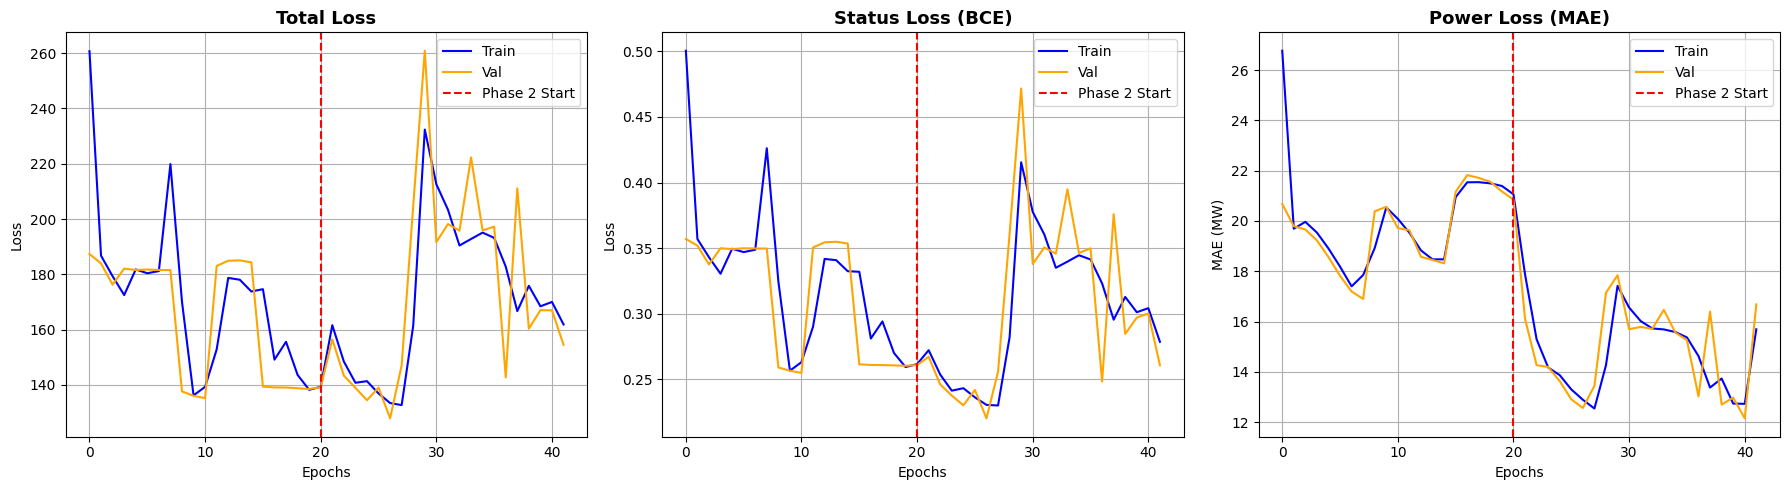

In [9]:
# ---------------------------------------------------------
# 8. Loss Curve 시각화 (Phase 1 & Phase 2 연결)
# ---------------------------------------------------------
import matplotlib.pyplot as plt

def plot_two_phase_loss(hist1, hist2):
    # 두 히스토리의 데이터 병합
    def merge_metric(metric_name):
        return hist1.history[metric_name] + hist2.history[metric_name]

    metrics = ['loss', 'val_loss',
               'out_status_loss', 'val_out_status_loss',
               'out_power_loss', 'val_out_power_loss']

    merged_data = {m: merge_metric(m) for m in metrics}
    phase1_epochs = len(hist1.history['loss'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 그래프 그리기 헬퍼 함수
    def plot_ax(ax, train_key, val_key, title, ylabel):
        ax.plot(merged_data[train_key], label='Train', color='blue')
        ax.plot(merged_data[val_key], label='Val', color='orange')
        # Phase 전환 지점 수직선 표시
        ax.axvline(x=phase1_epochs - 1, color='red', linestyle='--', label='Phase 2 Start')
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True)

    # 1. Total Loss
    plot_ax(axes[0], 'loss', 'val_loss', 'Total Loss', 'Loss')
    # 2. Status Loss (BCE)
    plot_ax(axes[1], 'out_status_loss', 'val_out_status_loss', 'Status Loss (BCE)', 'Loss')
    # 3. Power Loss (MAE) 🌟 [수정] 오차 함수가 MAE로 바뀌었으므로 타이틀을 변경합니다.
    plot_ax(axes[2], 'out_power_loss', 'val_out_power_loss', 'Power Loss (MAE)', 'MAE (MW)')

    plt.tight_layout()
    plt.show()

# 병합된 시각화 실행 (변수명 주의: history_phase1, history_phase2)
plot_two_phase_loss(history_phase1, history_phase2)

[Cell9]

In [10]:
# ---------------------------------------------------------
# [교정된 cell 9] Test Set 평가 (Multi-Input 스케일 버그 완벽 수정)
# ---------------------------------------------------------
import numpy as np

print("=== Test Set 물리적 제약 기반 최종 평가 시작 ===")

num_static_features = 4

# 1. 💡 [데이터 준비] 테스트용 데이터셋에서 초기 상태를 날것(MW) 그대로 추출
X_init_status_test = X_static_test[:, 0::num_static_features]
X_init_power_mw_test = X_static_test[:, 1::num_static_features]

# 2. 💡 [예측 수행] 4개의 다중 입력을 모델에 주입
pred_status, pred_power_scaled = model.predict([
    X_demand_test, 
    X_static_test, 
    X_init_status_test, 
    X_init_power_mw_test
])

# 3. 💡 [스케일 복원] 예측값과 정답지 모두 날것의 MW 단위로 매핑
pred_status_bin = (pred_status > 0.5).astype(int)

# 모델 출력층에서 복잡한 스케일러 없이 나왔으므로 그대로 사용하거나 필요한 경우에만 복원
pred_power_mw = pred_power_scaled 
true_power_mw = Y_power_test  # 🌟 변환 없이 정답 데이터셋을 그대로 진짜 MW로 사용!

# 제약 조건 검사용 상수 배열 정의
SYS_CAPACITY = 7220.0
P_MIN_np = np.array(P_min_vals)
P_MAX_np = np.array(P_max_vals)
RU_np = np.array(RU_vals)
RD_np = np.array(RD_vals)

# 수급 불균형 검사용 디맨드 추출
X_test_mw = X_demand_test.squeeze(-1)

# ---------------------------------------------------------
# ML 성능 및 수급 불균형 평가 (Mismatch)
# ---------------------------------------------------------
status_accuracy = np.mean(pred_status_bin == Y_status_test) * 100
power_mae = np.mean(np.abs(pred_power_mw - true_power_mw))

total_pred_power_mw = np.sum(pred_power_mw, axis=-1)
mismatch_mae = np.mean(np.abs(total_pred_power_mw - X_test_mw))

mean_actual_demand_mw = np.mean(X_test_mw)
relative_error_percent = (mismatch_mae / mean_actual_demand_mw) * 100

# ---------------------------------------------------------
# 물리적 제약 위반 (Violation) 검사
# ---------------------------------------------------------
ghost_power_mw = np.maximum(pred_power_mw, 0.0) * (1 - pred_status_bin)
mean_ghost_violation = np.mean(np.sum(ghost_power_mw, axis=-1))
ghost_relative_percent = (mean_ghost_violation / mean_actual_demand_mw) * 100

upper_violation = np.maximum(pred_power_mw - P_MAX_np, 0.0) * pred_status_bin
lower_violation = np.maximum(P_MIN_np - pred_power_mw, 0.0) * pred_status_bin
mean_capacity_violation = np.mean(np.sum(upper_violation + lower_violation, axis=-1))
capacity_relative_percent = (mean_capacity_violation / mean_actual_demand_mw) * 100

delta_p = pred_power_mw[:, 1:, :] - pred_power_mw[:, :-1, :]
stay_on_mask = pred_status_bin[:, 1:, :] * pred_status_bin[:, :-1, :]

ramp_up_violation = np.maximum(delta_p - RU_np, 0.0) * stay_on_mask
ramp_down_violation = np.maximum(-delta_p - RD_np, 0.0) * stay_on_mask
mean_ramp_violation = np.mean(np.sum(ramp_up_violation + ramp_down_violation, axis=-1))
ramp_relative_percent = (mean_ramp_violation / mean_actual_demand_mw) * 100

# =========================================================
# 💡 [비용 평가] AI 예측 비용 vs CPLEX 정답지 비용 비교 분석
# =========================================================
def calculate_total_cost_from_numpy(status_arr, power_mw_arr, linear_cost, noload_cost, su_cost):
    samples, hours, gens = status_arr.shape
    total_cost_per_sample = []
    
    for s in range(samples):
        sample_cost = 0
        status = status_arr[s]
        power = power_mw_arr[s]
        
        for t in range(hours):
            # 1. 운전 비용 = (선형 비용 * P) + (무부하 유지 비용 * Status)
            op_cost = np.sum(linear_cost * power[t] + noload_cost * status[t])
            
            # 2. 기동 비용 (Startup Cost)
            if t == 0:
                su_events = np.maximum(status[t] - 0, 0)
            else:
                su_events = np.maximum(status[t] - status[t-1], 0)
            
            st_cost = np.sum(su_cost * su_events)
            sample_cost += (op_cost + st_cost)
            
        total_cost_per_sample.append(sample_cost)
        
    return np.mean(total_cost_per_sample)

# 🌟 비용 계산용 변수 설정 (정답 데이터 그대로 주입)
Y_power_mw_test = true_power_mw  

ai_avg_cost = calculate_total_cost_from_numpy(pred_status_bin, pred_power_mw, LINEAR_COST_VALS, NOLOAD_COST_VALS, SU_COST_VALS)
cplex_avg_cost = calculate_total_cost_from_numpy(Y_status_test, Y_power_mw_test, LINEAR_COST_VALS, NOLOAD_COST_VALS, SU_COST_VALS)

cost_diff = ai_avg_cost - cplex_avg_cost
cost_diff_percent = (cost_diff / cplex_avg_cost) * 100

def calculate_overall_mut_mdt_metrics(all_pred_status, mut_vals, mdt_vals):
    num_samples, num_hours, num_gens = all_pred_status.shape
    
    total_mut_violation_hours = 0
    total_mdt_violation_hours = 0
    total_startup_events = 0
    total_shutdown_events = 0
    
    for s in range(num_samples):
        for g in range(num_gens):
            mut = mut_vals[g]
            mdt = mdt_vals[g]
            status = all_pred_status[s, :, g]
            
            for t in range(1, num_hours):
                if status[t-1] == 0 and status[t] == 1:
                    total_startup_events += 1
                    check_len = min(mut, num_hours - t)
                    actual_on = np.sum(status[t : t+check_len])
                    if actual_on < check_len:
                        total_mut_violation_hours += (check_len - actual_on)
                        
                elif status[t-1] == 1 and status[t] == 0:
                    total_shutdown_events += 1
                    check_len = min(mdt, num_hours - t)
                    actual_on = np.sum(status[t : t+check_len])
                    if actual_on > 0:
                        total_mdt_violation_hours += actual_on

    avg_mut_violation_per_sample = total_mut_violation_hours / num_samples
    avg_mdt_violation_per_sample = total_mdt_violation_hours / num_samples
    
    print(f"{'='*30}\n[Overall Performance & Physical Constraints]\n{'='*30}")
    print(f"Generator Status (On/Off) Accuracy: {status_accuracy:.2f}%")
    print(f"Mean Absolute Error (MAE) of Power Generation: {power_mae:.2f} MW")
    print(f"Power Balance Violation (Mismatch): {mismatch_mae:.2f} MW ({relative_error_percent:.2f}% NMAE)")
    print(f"Ghost Power Violation: {mean_ghost_violation:.2f} MW ({ghost_relative_percent:.2f}%)")
    print(f"Capacity Violation: {mean_capacity_violation:.2f} MW ({capacity_relative_percent:.2f}%)")
    print(f"Ramp Rate Violation: {mean_ramp_violation:.2f} MW ({ramp_relative_percent:.2f}%)")

    print(f"{'='*30}\n[Economic Evaluation]\n{'='*30}")
    print(f"Average Daily Cost (CPLEX Ground Truth): ${cplex_avg_cost:,.2f}")
    print(f"Average Daily Cost (AI Prediction): ${ai_avg_cost:,.2f}")
    if cost_diff > 0:
        print(f"Cost Difference: The AI model's scheduling is ${cost_diff:,.2f} (+{cost_diff_percent:.2f}%) more expensive than the CPLEX optimal solution.")
    else:
        print(f"Cost Difference: The AI model's scheduling is ${abs(cost_diff):,.2f} ({cost_diff_percent:.2f}%) cheaper than the CPLEX optimal solution.")

    print(f"{'='*30}\n[Temporal Constraints]\n{'='*30}")
    print(f"Average Minimum Up Time (MUT) Violation: {avg_mut_violation_per_sample:.2f} hours/sample")
    print(f"Average Minimum Down Time (MDT) Violation: {avg_mdt_violation_per_sample:.2f} hours/sample")

calculate_overall_mut_mdt_metrics(pred_status_bin, MUT_VALS, MDT_VALS)

=== Test Set 물리적 제약 기반 최종 평가 시작 ===
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
[Overall Performance & Physical Constraints]
Generator Status (On/Off) Accuracy: 96.02%
Mean Absolute Error (MAE) of Power Generation: 12.53 MW
Power Balance Violation (Mismatch): 514.32 MW (13.52% NMAE)
Ghost Power Violation: 0.00 MW (0.00%)
Capacity Violation: 0.00 MW (0.00%)
Ramp Rate Violation: 0.00 MW (0.00%)
[Economic Evaluation]
Average Daily Cost (CPLEX Ground Truth): $974,261.77
Average Daily Cost (AI Prediction): $925,463.11
Cost Difference: The AI model's scheduling is $48,798.66 (-5.01%) cheaper than the CPLEX optimal solution.
[Temporal Constraints]
Average Minimum Up Time (MUT) Violation: 0.00 hours/sample
Average Minimum Down Time (MDT) Violation: 0.00 hours/sample


[Cell10]

=== 개별 샘플 심층 시각화 분석 (Multi-Input 및 노-스케일링 반영) ===


/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from fo

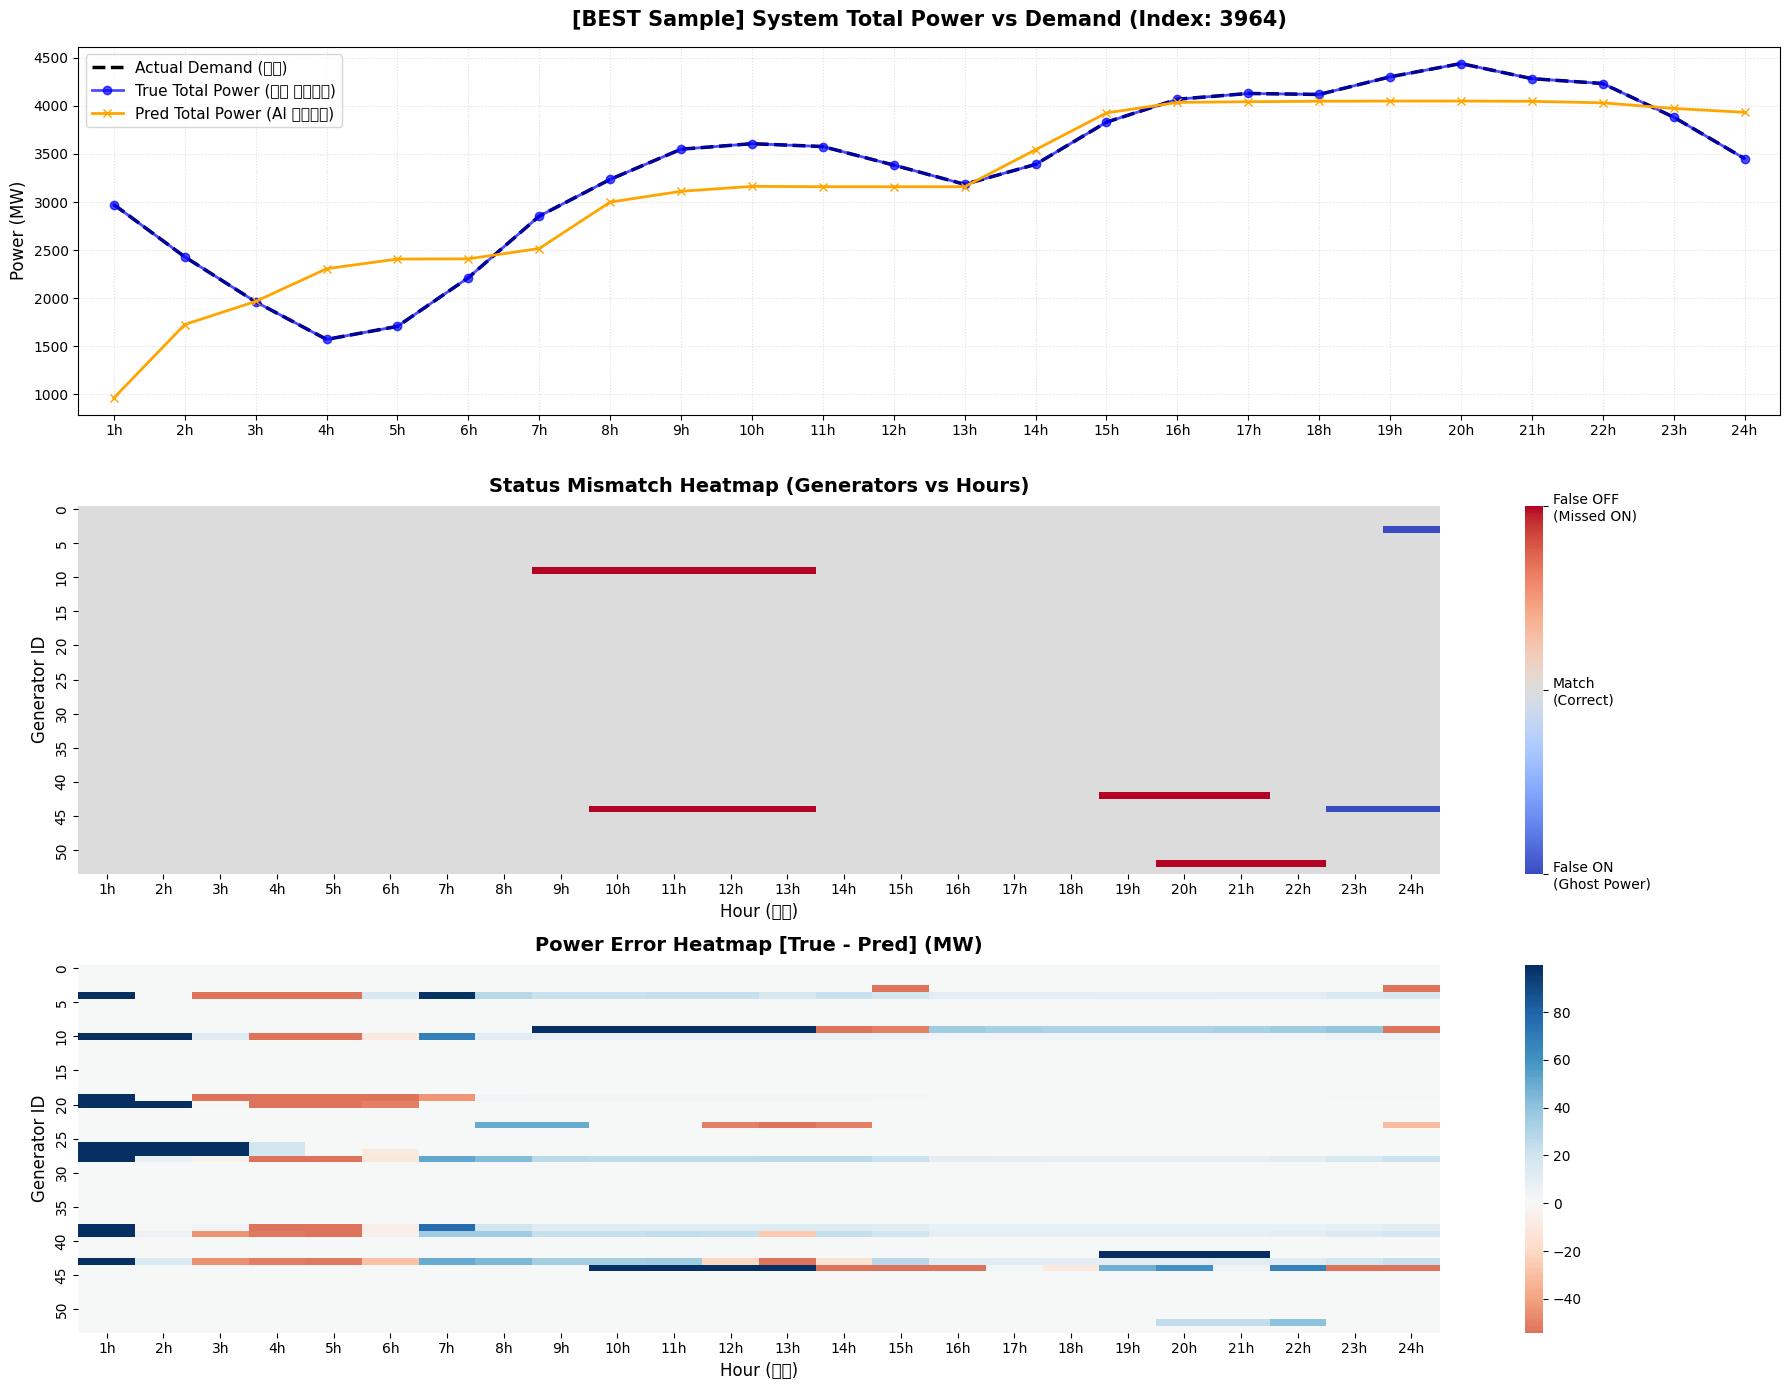

/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from fo

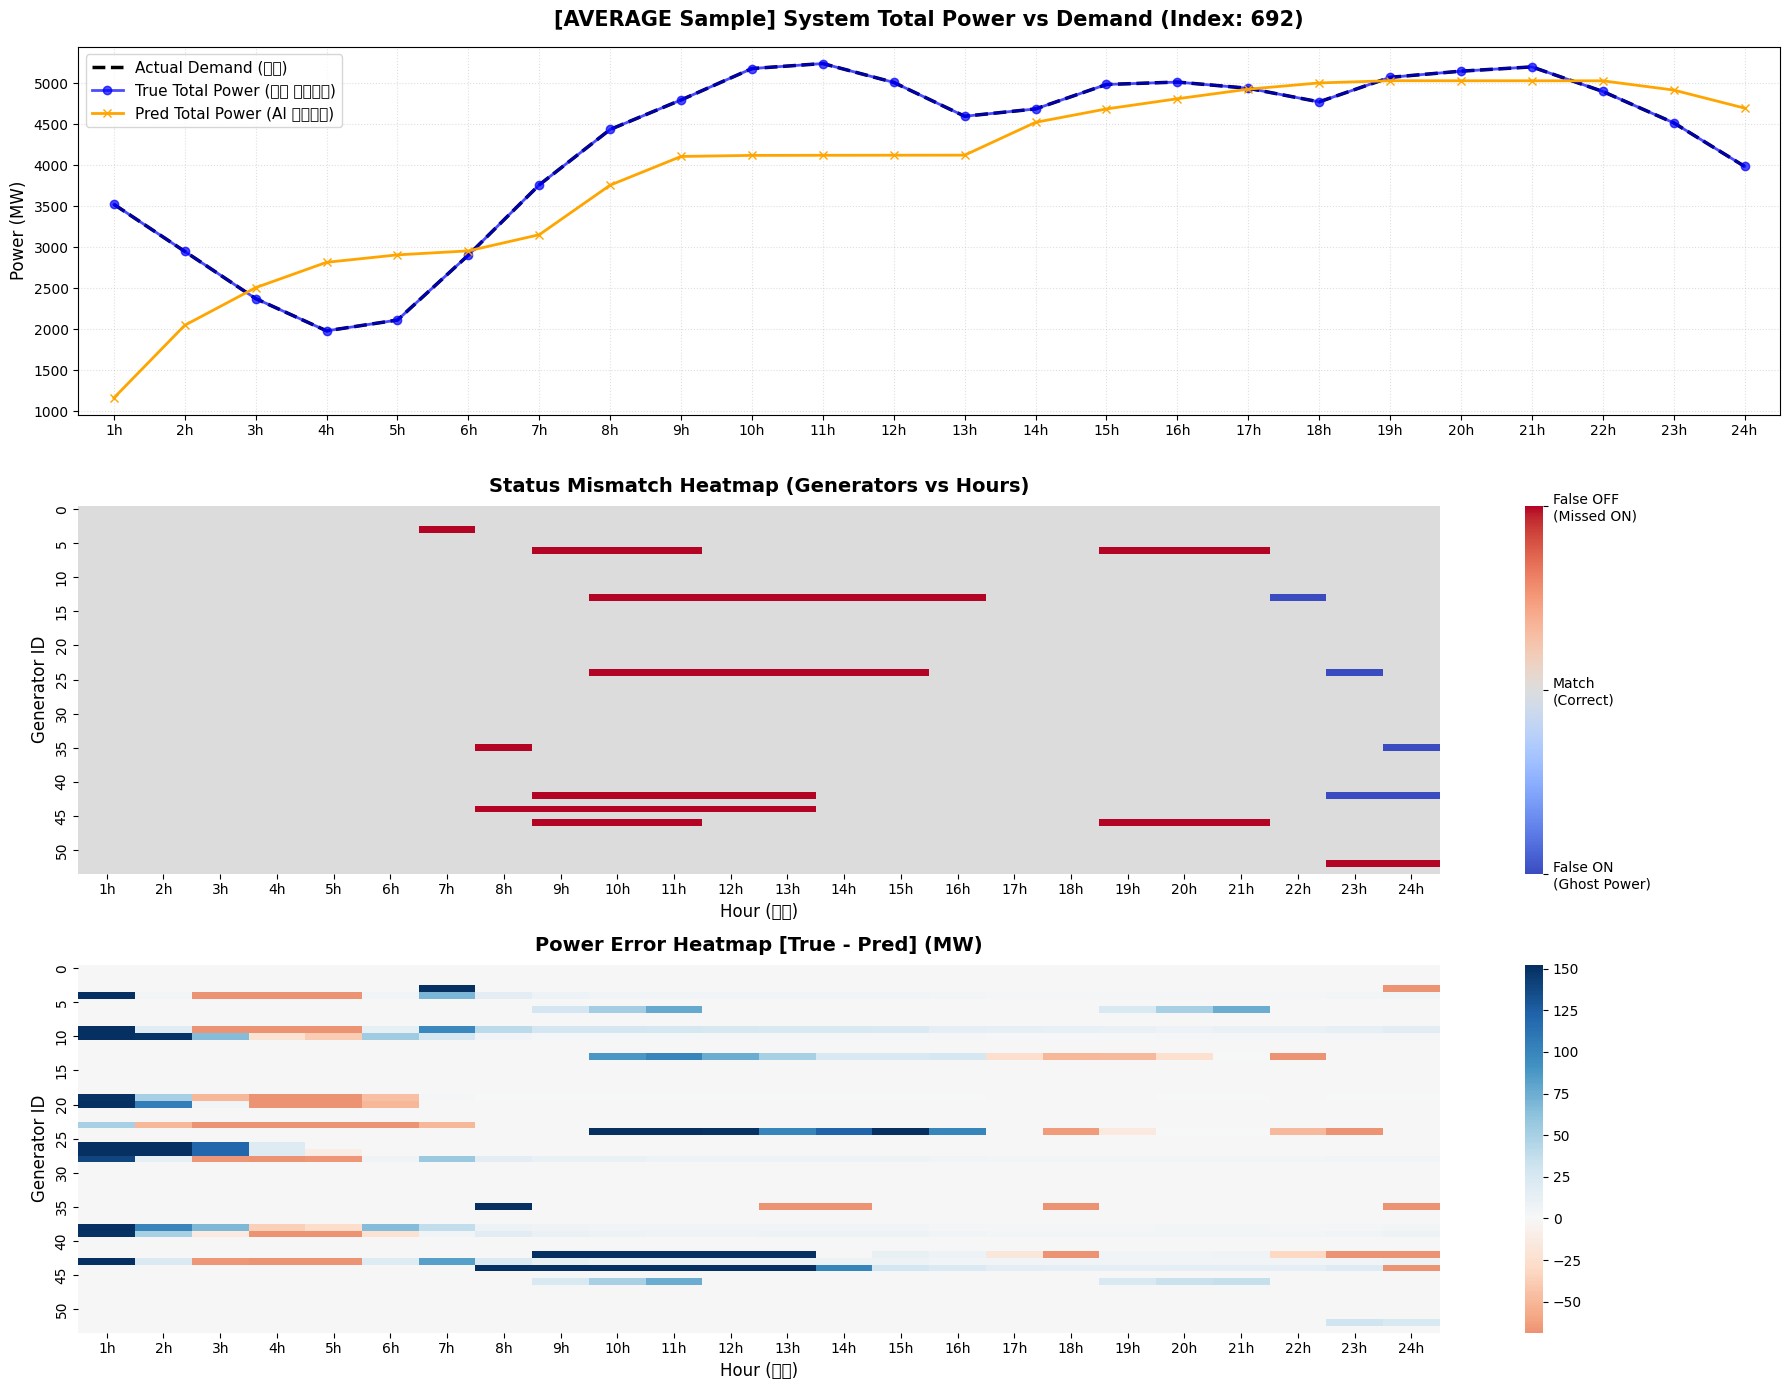

/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/work/.local/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48156 (\N{HANGUL SYLLABLE BAL}) missing from fo

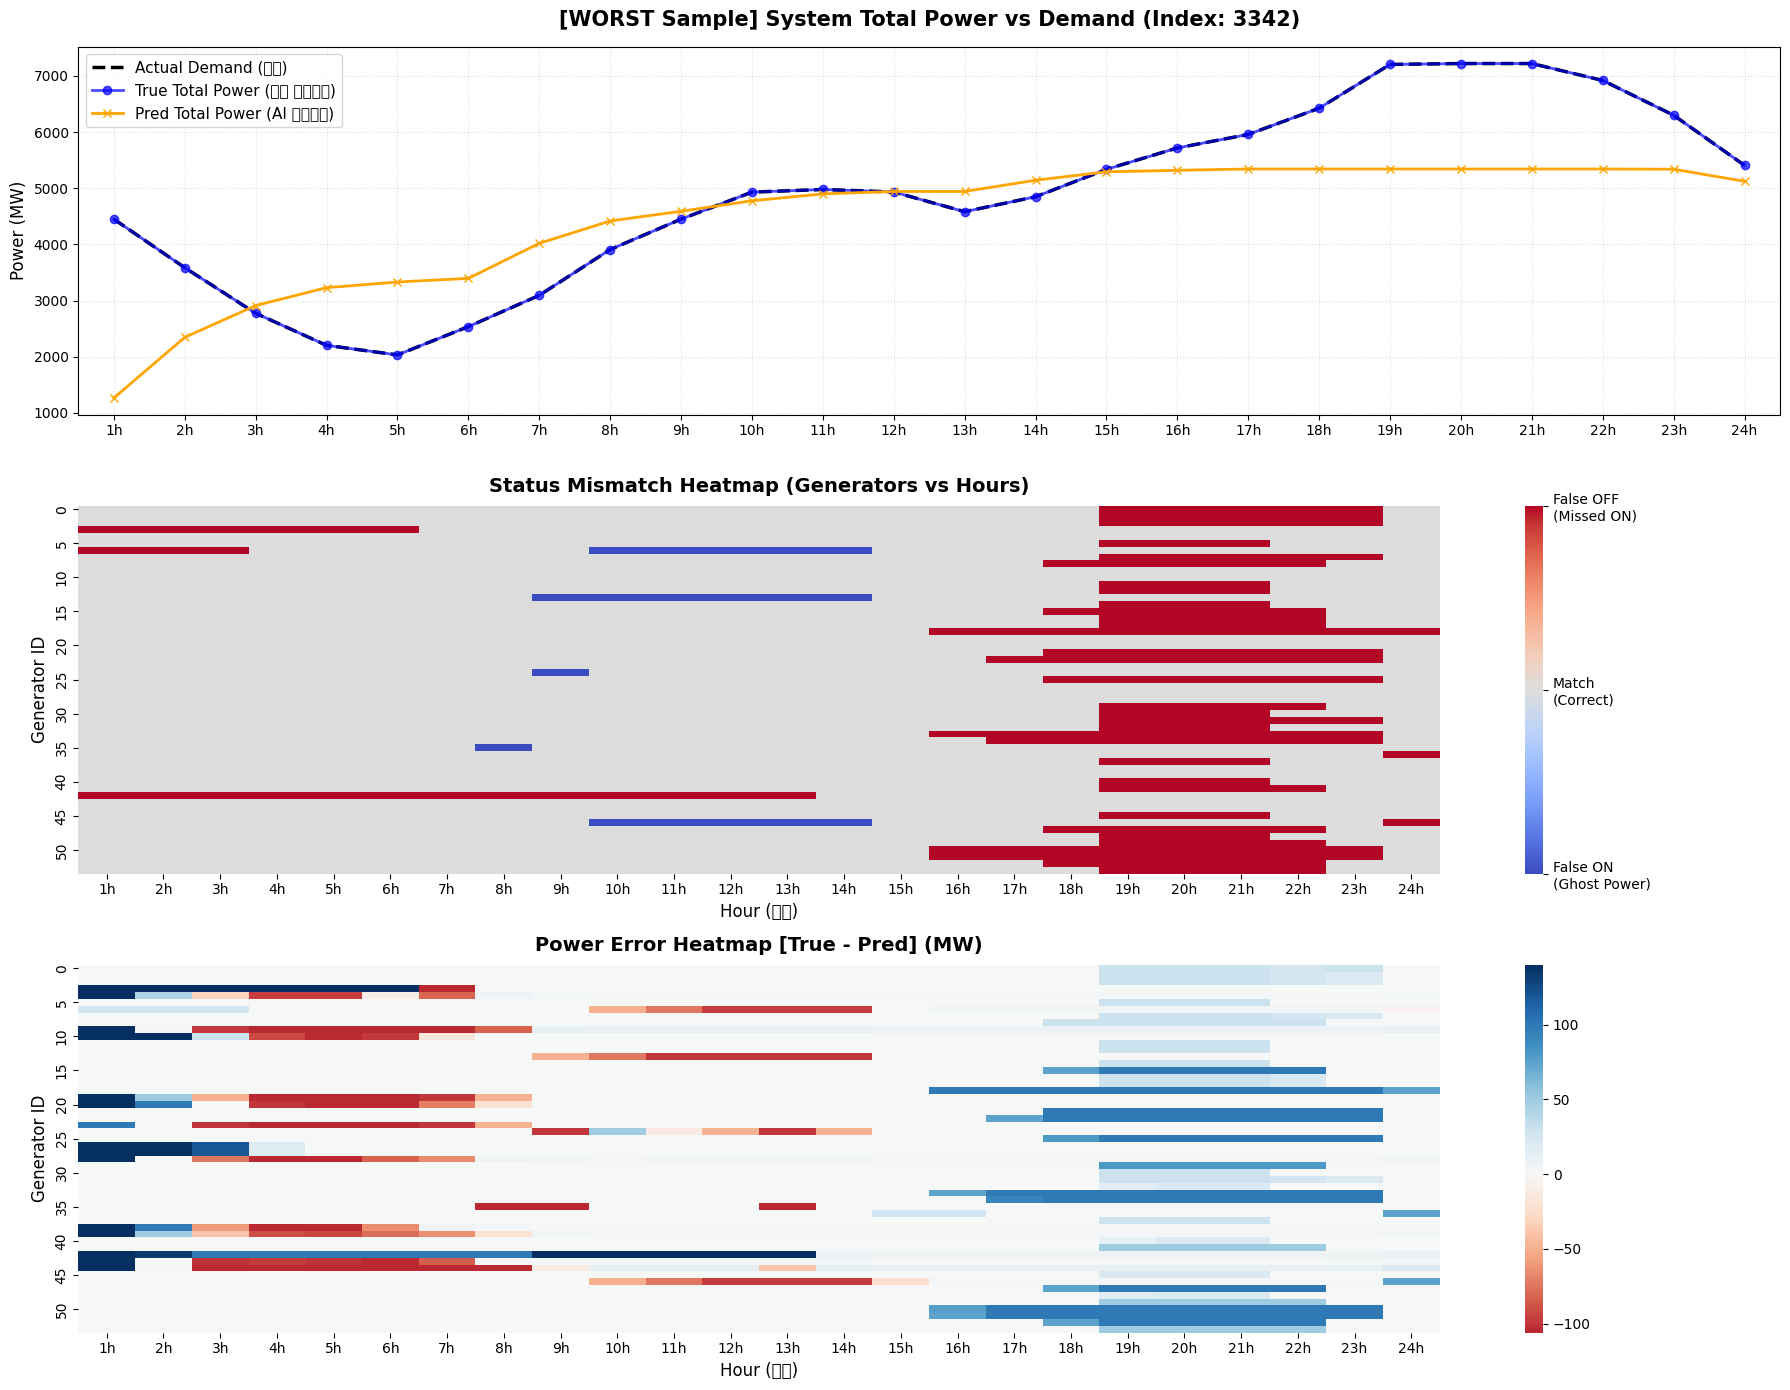

In [11]:
# ---------------------------------------------------------
# [수정된 cell 10] 개별 샘플 심층 시각화 분석 (노-스케일링 버전)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== 개별 샘플 심층 시각화 분석 (Multi-Input 및 노-스케일링 반영) ===")

# 🌟 날것의 MW 단위이므로 복잡한 역변환 없이 곧바로 오차 계산이 가능합니다.
sample_power_errors = np.mean(np.abs(pred_power_mw - true_power_mw), axis=(1, 2))

best_idx = np.argmin(sample_power_errors)
worst_idx = np.argmax(sample_power_errors)
median_error = np.median(sample_power_errors)
avg_idx = np.argmin(np.abs(sample_power_errors - median_error))

def plot_sample_analysis(idx, title_prefix="Sample"):
    fig = plt.figure(figsize=(18, 14))

    # 해당 샘플의 24시간 데이터 추출
    t_demand = X_test_mw[idx]
    t_true_power_total = np.sum(true_power_mw[idx], axis=1)
    t_pred_power_total = np.sum(pred_power_mw[idx], axis=1)

    # 오차 매트릭스 계산 (시간 축 정렬을 위해 전치(.T)하기 전 상태 유지)
    status_diff = Y_status_test[idx] - pred_status_bin[idx]
    power_diff = true_power_mw[idx] - pred_power_mw[idx]

    # 공통 시간 레이블 정의
    hour_labels = [f"{h+1}h" for h in range(NUM_HOURS)]

    # ---------------------------------------------------------
    # 📈 [Subplot 1] 계통 총 발전량 vs 총 수요 곡선
    # ---------------------------------------------------------
    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(t_demand, label='Actual Demand (수요)', color='black', linestyle='--', linewidth=2.5)
    ax1.plot(t_true_power_total, label='True Total Power (정답 총발전량)', color='blue', linewidth=2, marker='o', alpha=0.7)
    ax1.plot(t_pred_power_total, label='Pred Total Power (AI 총발전량)', color='orange', linewidth=2, marker='x')

    ax1.set_title(f"[{title_prefix}] System Total Power vs Demand (Index: {idx})", fontsize=15, fontweight='bold', pad=15)
    ax1.set_ylabel("Power (MW)", fontsize=12)
    ax1.set_xlim(-0.5, NUM_HOURS - 0.5)
    ax1.set_xticks(range(NUM_HOURS))
    ax1.set_xticklabels(hour_labels)
    ax1.legend(loc='upper left', fontsize=11)
    ax1.grid(True, alpha=0.4, linestyle=':')

    # ---------------------------------------------------------
    # 🔥 [Subplot 2] 발전기 기동 상태(Status) 불일치 히트맵
    # ---------------------------------------------------------
    ax2 = plt.subplot(3, 1, 2)
    # y축에 발전기가 너무 많으므로 yticklabels는 5개 간격으로 축소하여 시각적 피로를 줄입니다.
    sns.heatmap(status_diff.T, cmap='coolwarm', center=0,
                cbar_kws={'ticks': [-1, 0, 1]}, ax=ax2,
                xticklabels=hour_labels, yticklabels=5)

    ax2.set_title("Status Mismatch Heatmap (Generators vs Hours)", fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel("Generator ID", fontsize=12)
    ax2.set_xlabel("Hour (시간)", fontsize=12)

    # 컬러바 레이블 정돈
    cbar = ax2.collections[0].colorbar
    cbar.set_ticklabels(['False ON\n(Ghost Power)', 'Match\n(Correct)', 'False OFF\n(Missed ON)'])
    cbar.ax.tick_params(labelsize=10)

    # ---------------------------------------------------------
    # ❄️ [Subplot 3] 발전기 개별 발전량 오차 히트맵 [정답 - 예측]
    # ---------------------------------------------------------
    ax3 = plt.subplot(3, 1, 3)
    # RdBu 맵을 사용하여 AI가 과대 예측하면 파란색, 과소 예측하면 빨간색 계열로 표출됩니다.
    sns.heatmap(power_diff.T, cmap='RdBu', center=0, ax=ax3, robust=True,
                xticklabels=hour_labels, yticklabels=5)

    ax3.set_title("Power Error Heatmap [True - Pred] (MW)", fontsize=14, fontweight='bold', pad=10)
    ax3.set_ylabel("Generator ID", fontsize=12)
    ax3.set_xlabel("Hour (시간)", fontsize=12)

    plt.tight_layout()
    plt.show()

# 🌟 최종 정의된 3가지 케이스에 대해 깊이 있는 시각화 실행
plot_sample_analysis(best_idx, title_prefix="BEST Sample")
plot_sample_analysis(avg_idx, title_prefix="AVERAGE Sample")
plot_sample_analysis(worst_idx, title_prefix="WORST Sample")

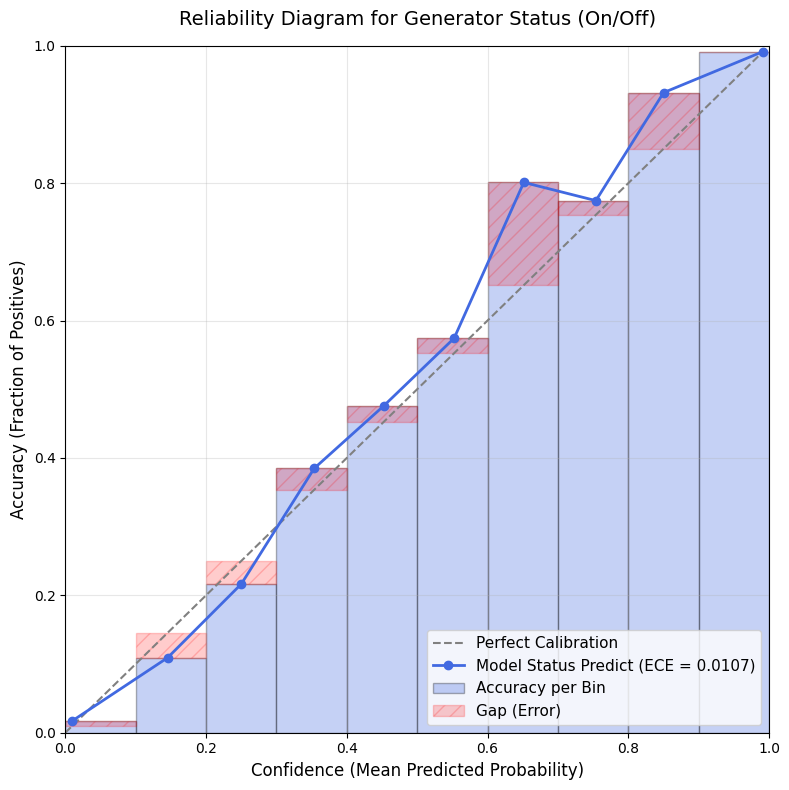

--------------------------------------------------
🎯 Status(On/Off) Expected Calibration Error (ECE): 0.0107
--------------------------------------------------


In [12]:
# ECE - reliability diagram - on out_status
import numpy as np
import matplotlib.pyplot as plt

def calculate_ece_and_plot_reliability(y_true, y_prob, n_bins=10):
    """
    발전기 On/Off 상태에 대한 ECE(Expected Calibration Error)를 계산하고,
    Reliability Diagram을 시각화하는 함수입니다.
    """
    # 3D 배열(batch_size, num_hours, num_gens)을 1차원으로 펼치기
    y_true = y_true.flatten()
    y_prob = y_prob.flatten()

    # 0부터 1까지의 확률 공간을 n_bins 개수로 분할
    bins = np.linspace(0.0, 1.0, n_bins + 1)

    bin_accs = []
    bin_confs = []
    bin_counts = []
    ece = 0.0

    for i in range(n_bins):
        # 각 구간(bin)의 하한과 상한
        lower, upper = bins[i], bins[i+1]

        # 마지막 bin은 1.0을 포함하도록 설정
        if i == n_bins - 1:
            in_bin = (y_prob >= lower) & (y_prob <= upper)
        else:
            in_bin = (y_prob >= lower) & (y_prob < upper)

        prob_in_bin = y_prob[in_bin]
        true_in_bin = y_true[in_bin]
        n_in_bin = len(prob_in_bin)

        if n_in_bin > 0:
            accuracy = np.mean(true_in_bin)
            confidence = np.mean(prob_in_bin)

            bin_accs.append(accuracy)
            bin_confs.append(confidence)
            bin_counts.append(n_in_bin)

            # ECE 누적 계산: |정확도 - 신뢰도| * (해당 구간 샘플 비율)
            ece += np.abs(accuracy - confidence) * (n_in_bin / len(y_prob))
        else:
            bin_accs.append(0.0)
            bin_confs.append(0.0)
            bin_counts.append(0)

    bin_accs = np.array(bin_accs)
    bin_confs = np.array(bin_confs)
    bin_counts = np.array(bin_counts)

    # ==========================================
    # Reliability Diagram 시각화
    # ==========================================
    plt.figure(figsize=(8, 8), dpi=100)

    # 기준선 (완벽한 캘리브레이션: Confidence == Accuracy)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

    # 캘리브레이션 꺾은선 (데이터가 존재하는 구간만)
    valid = bin_counts > 0
    plt.plot(bin_confs[valid], bin_accs[valid], marker='o',
             linewidth=2, color='royalblue', label=f'Model Status Predict (ECE = {ece:.4f})')

    # Accuracy 막대 그래프
    bin_centers = bins[:-1] + (1.0 / n_bins) / 2
    plt.bar(bin_centers[valid], bin_accs[valid], width=1.0/n_bins,
            color='royalblue', alpha=0.3, edgecolor='black', label='Accuracy per Bin')

    # Gap 표시 (신뢰도와 정확도의 차이)
    gaps = bin_confs - bin_accs
    for i in range(n_bins):
        if valid[i] and gaps[i] != 0:
            # Overconfidence(빨간 빗금) 혹은 Underconfidence 표시
            plt.bar(bin_centers[i], gaps[i], bottom=bin_accs[i], width=1.0/n_bins,
                    color='red', alpha=0.2, edgecolor='red', hatch='//')

    # 범례에 Gap 표시를 깔끔하게 추가하기 위한 더미
    plt.bar([-1], [0], color='red', alpha=0.2, edgecolor='red', hatch='//', label='Gap (Error)')

    plt.xlim(0, 1.0)
    plt.ylim(0, 1.0)
    plt.xlabel('Confidence (Mean Predicted Probability)', fontsize=12)
    plt.ylabel('Accuracy (Fraction of Positives)', fontsize=12)
    plt.title('Reliability Diagram for Generator Status (On/Off)', fontsize=14, pad=15)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("-" * 50)
    print(f"🎯 Status(On/Off) Expected Calibration Error (ECE): {ece:.4f}")
    print("-" * 50)

    return ece

# 기존 평가 코드의 변수를 그대로 사용하여 함수 실행
# (19번째 셀에 있는 Y_status_test와 pred_status 사용)
ece_value = calculate_ece_and_plot_reliability(Y_status_test, pred_status, n_bins=10)

/tmp/ipykernel_13235/2506749830.py:25: RuntimeWarning: divide by zero encountered in log2
  entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
/tmp/ipykernel_13235/2506749830.py:25: RuntimeWarning: invalid value encountered in multiply
  entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)



🎯 Status(On/Off) Predictive Entropy (불확실성) 평가
전체 평균 엔트로피       : 0.1463 bits
정답을 맞춘 예측의 엔트로피: 0.1266 bits
틀린 예측의 엔트로피      : 0.6276 bits
--------------------------------------------------
🔵 파란색(정답) 최고 밀도 (Density Peak Y값): 24.1026
🔴 빨간색(오답) 최고 밀도 (Density Peak Y값): 9.9134


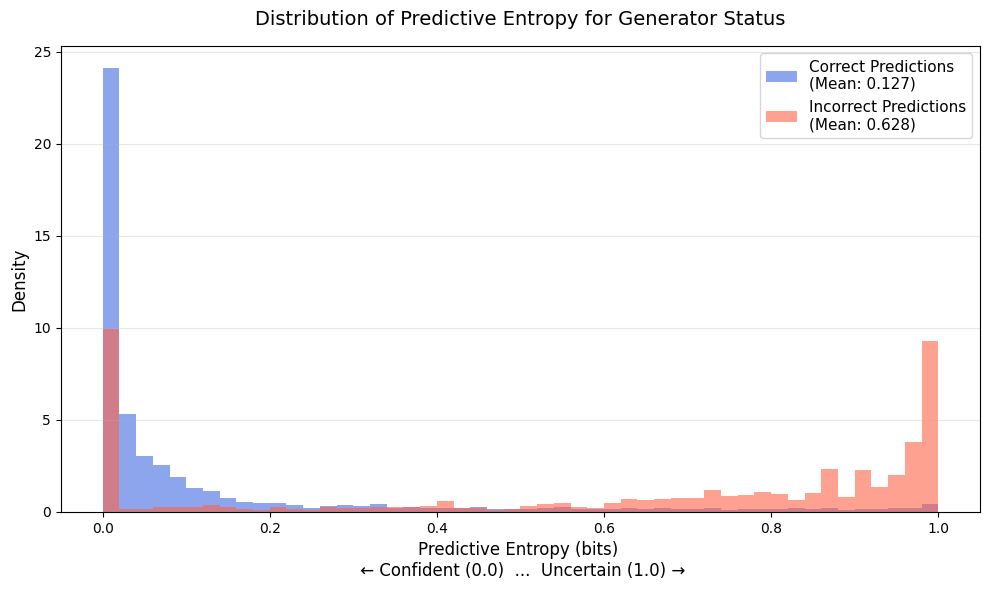

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_predictive_entropy(y_true, y_prob):
    """
    발전기 On/Off 예측 확률에 대한 이진 엔트로피(Shannon Entropy)를 계산하고,
    정답/오답 그룹별 엔트로피 분포를 시각화합니다.
    """
    # 1. NaN 체크 및 전처리 (디버깅용)
    nan_count = np.isnan(y_prob).sum()
    if nan_count > 0:
        print(f"⚠️ 경고: pred_status에 {nan_count}개의 NaN이 포함되어 있습니다!")
        # NaN을 0.5로 치환 (엔트로피 최대값인 1.0으로 유도하여 '완전한 불확실성'으로 취급)
        y_prob = np.nan_to_num(y_prob, nan=0.5)

    # 2. 3D 배열을 1차원으로 펼치기
    y_true = y_true.flatten()
    y_prob = y_prob.flatten()

    # log(0) 에러를 방지하기 위해 확률값을 미세하게 조정 (클리핑)
    eps = 1e-15
    p = np.clip(y_prob, eps, 1 - eps)

    # 이진 엔트로피 계산 (단위: bits, 밑이 2인 로그 사용)
    entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

    # 전체 평균 엔트로피 (안전하게 nanmean 사용)
    mean_entropy = np.nanmean(entropy)

    # 예측 성공 여부에 따른 마스크 생성 (0.5 기준 이진화)
    y_pred_bin = (y_prob > 0.5).astype(int)
    correct_mask = (y_pred_bin == y_true)
    incorrect_mask = (y_pred_bin != y_true)

    # 정답/오답 그룹별 엔트로피 배열 생성
    entropy_correct = entropy[correct_mask]
    entropy_incorrect = entropy[incorrect_mask]

    # 그룹별 평균 엔트로피 (안전하게 nanmean 사용)
    mean_entropy_correct = np.nanmean(entropy_correct) if len(entropy_correct) > 0 else 0
    mean_entropy_incorrect = np.nanmean(entropy_incorrect) if len(entropy_incorrect) > 0 else 0

    # 결과 텍스트 출력
    print("\n" + "="*50)
    print("🎯 Status(On/Off) Predictive Entropy (불확실성) 평가")
    print("="*50)
    print(f"전체 평균 엔트로피       : {mean_entropy:.4f} bits")
    print(f"정답을 맞춘 예측의 엔트로피: {mean_entropy_correct:.4f} bits")
    print(f"틀린 예측의 엔트로피      : {mean_entropy_incorrect:.4f} bits")
    print("-" * 50)

    # 히스토그램을 그리기 전 혹시 모를 NaN 값을 최종 필터링하여 그래프 오류 방지
    valid_correct = entropy_correct[~np.isnan(entropy_correct)]
    valid_incorrect = entropy_incorrect[~np.isnan(entropy_incorrect)]

    # ==========================================
    # 엔트로피 분포 시각화 (히스토그램)
    # ==========================================
    # ==========================================
    # 엔트로피 분포 시각화 및 최고 밀도(Density Peak) 출력
    # ==========================================
    plt.figure(figsize=(10, 6), dpi=100)

    # 정답을 맞춘 그룹 (파란색)
    if len(valid_correct) > 0:
        # n_c에 각 막대의 높이(밀도)가 저장됩니다.
        n_c, bins_c, patches_c = plt.hist(valid_correct, bins=50, alpha=0.6, color='royalblue',
                 label=f'Correct Predictions\n(Mean: {mean_entropy_correct:.3f})', density=True)

        # 가장 높은 막대의 높이 찾기
        max_density_c = np.max(n_c)
        print(f"🔵 파란색(정답) 최고 밀도 (Density Peak Y값): {max_density_c:.4f}")

    # 틀린 그룹 (빨간색)
    if len(valid_incorrect) > 0:
        # n_i에 각 막대의 높이(밀도)가 저장됩니다.
        n_i, bins_i, patches_i = plt.hist(valid_incorrect, bins=50, alpha=0.6, color='tomato',
                 label=f'Incorrect Predictions\n(Mean: {mean_entropy_incorrect:.3f})', density=True)

        # 가장 높은 막대의 높이 찾기
        max_density_i = np.max(n_i)
        print(f"🔴 빨간색(오답) 최고 밀도 (Density Peak Y값): {max_density_i:.4f}")

    plt.xlabel('Predictive Entropy (bits) \n ← Confident (0.0)  ...  Uncertain (1.0) →', fontsize=12)
    # ... (나머지 그래프 설정 코드는 동일) ...

    plt.xlabel('Predictive Entropy (bits) \n ← Confident (0.0)  ...  Uncertain (1.0) →', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Distribution of Predictive Entropy for Generator Status', fontsize=14, pad=15)
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return entropy

# ---------------------------------------------------------
# 함수 실행
# ---------------------------------------------------------
# 기존 평가 코드의 예측 결과(pred_status)와 실제값(Y_status_test)을 그대로 활용합니다.
entropy_values = evaluate_predictive_entropy(Y_status_test, pred_status)

In [14]:
# 2D loss landscape
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import tensorflow as tf

def generate_normalized_random_direction(weights):
    """
    원본 가중치와 동일한 형태의 무작위 방향 벡터를 생성하고,
    Filter-wise Normalization을 적용하여 스케일을 맞춥니다.
    """
    direction = []
    for w in weights:
        # 가중치와 같은 형태의 가우시안 노이즈 생성
        d = np.random.randn(*w.shape).astype(np.float32)

        # 가중치와 방향 벡터의 노름(Norm) 계산 (필터 단위)
        w_norm = np.linalg.norm(w)
        d_norm = np.linalg.norm(d)

        # 방향 벡터의 스케일을 원래 가중치 스케일로 정규화
        if d_norm > 0:
            d = d * (w_norm / d_norm)
        direction.append(d)
    return direction

def plot_2d_loss_landscape(model, X_val, Y_val, grid_size=15, alpha_max=1.0):
    """
    중심점(학습된 가중치) 주변의 2D Loss Landscape를 평가하고 3D 및 등고선으로 시각화합니다.
    - grid_size: 격자 크기 (예: 15x15 = 225번 평가. 클수록 정밀하지만 오래 걸림)
    - alpha_max: 탐색 반경 (1.0이면 가중치 크기만큼 주변을 탐색)
    """
    print(f"탐색을 시작합니다. 총 {grid_size * grid_size}번의 모델 평가가 진행됩니다. (잠시 대기)")

    # 1. 원본(최적화된) 가중치 저장
    original_weights = model.get_weights()

    # 2. 서로 직교하는 두 개의 무작위 방향 벡터 생성
    dir_x = generate_normalized_random_direction(original_weights)
    dir_y = generate_normalized_random_direction(original_weights)

    # 3. 탐색 격자(Grid) 생성
    alpha_range = np.linspace(-alpha_max, alpha_max, grid_size)
    beta_range = np.linspace(-alpha_max, alpha_max, grid_size)
    A, B = np.meshgrid(alpha_range, beta_range)
    Loss_Surface = np.zeros_like(A)

    # 4. 격자 공간을 돌며 Loss 평가
    total_steps = grid_size * grid_size
    step_count = 0

    for i in range(grid_size):
        for j in range(grid_size):
            a = A[i, j]
            b = B[i, j]

            # W_new = W_origin + a * dir_x + b * dir_y
            new_weights = []
            for w_orig, dx, dy in zip(original_weights, dir_x, dir_y):
                w_new = w_orig + (a * dx) + (b * dy)
                new_weights.append(w_new)

            model.set_weights(new_weights)

            # 검증 데이터셋에 대한 Total Loss 평가
            eval_result = model.evaluate(X_val, Y_val, verbose=0)
            Loss_Surface[i, j] = eval_result[0] # eval_result[0]는 total_loss

            step_count += 1
            if step_count % 20 == 0 or step_count == total_steps:
                print(f"진행 상황: {step_count}/{total_steps} 완료")

    # 5. 모델을 다시 원래 가중치로 복원 (매우 중요)
    model.set_weights(original_weights)
    print("평가 완료! 원본 가중치로 복원되었습니다. 시각화를 준비합니다.")

  # ==========================================
    # 6. 시각화 (3D Surface & 2D Contour)
    # ==========================================
    fig = plt.figure(figsize=(14, 6))

    # 극단적으로 큰 Loss 값들 때문에 지형이 안 보일 수 있으므로 로그 스케일 적용
    Log_Loss = np.log1p(Loss_Surface)

    # [왼쪽] 3D Surface Plot
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf = ax1.plot_surface(A, B, Log_Loss, cmap='viridis', edgecolor='none', alpha=0.8)
    ax1.set_title('3D Loss Surface (Log Scale)', fontsize=14)
    ax1.set_xlabel('Direction X', fontsize=12)
    ax1.set_ylabel('Direction Y', fontsize=12)
    ax1.set_zlabel('Log(Loss)', fontsize=12)

    # 🚨 수정된 부분: ax1=ax1 을 ax=ax1 로 변경
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

    # [오른쪽] 2D Contour Plot (등고선)
    ax2 = fig.add_subplot(1, 2, 2)
    contour = ax2.contourf(A, B, Log_Loss, levels=30, cmap='viridis')
    ax2.plot(0, 0, 'r*', markersize=15, label='Current Model (Minimum)') # 현재 모델 위치
    ax2.set_title('2D Loss Contour', fontsize=14)
    ax2.set_xlabel('Direction X', fontsize=12)
    ax2.set_ylabel('Direction Y', fontsize=12)
    ax2.legend(loc='upper right')

    # 🚨 수정된 부분: ax2=ax2 를 ax=ax2 로 변경
    fig.colorbar(contour, ax=ax2)

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 함수 실행 (검증 데이터를 입력으로 제공)
# ---------------------------------------------------------
X_val_data = [X_demand_val, X_static_val]
Y_val_data = {'out_status': Y_status_val, 'out_power': Y_power_val}

# grid_size=15는 약 225번 평가를 의미합니다. 더 정밀한 지형을 원하면 20~30으로 늘리세요.
plot_2d_loss_landscape(model, X_val_data, Y_val_data, grid_size=15, alpha_max=1.0)

탐색을 시작합니다. 총 225번의 모델 평가가 진행됩니다. (잠시 대기)


ValueError: Layer "functional" expects 4 input(s), but it received 2 input tensors. Inputs received: [<tf.Tensor 'data:0' shape=(None, 24, 1) dtype=float32>, <tf.Tensor 'data_1:0' shape=(None, 216) dtype=float32>]

In [ ]:
#SHAP

import numpy as np
import shap
import tensorflow as tf
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# 자바스크립트 시각화 모듈 초기화
shap.initjs()

TARGET_GEN_IDX = 0  # 분석할 발전기 인덱스
NUM_STATIC_FEATURES = 4 # P_max, P_min, RU, RD

# ==========================================
# 1. 3D 출력을 1D 스칼라(하루 총합)로 압축하는 레이어 생성
# ==========================================
# SHAP은 (batch, 1) 형태의 출력만 안정적으로 해석할 수 있습니다.
# 타겟 발전기의 24시간 전체 상태/발전량을 합산하여 하나의 분석 목표(Target)로 만듭니다.
def get_daily_sum(x):
    # x shape: (batch_size, 24, 54)
    # 특정 발전기 추출 (batch, 24) -> 시간 합산 (batch, 1)
    gen_output = x[:, :, TARGET_GEN_IDX]
    return tf.reduce_sum(gen_output, axis=1, keepdims=True)

# ==========================================
# 2. 두 개의 개별 Sub-model 생성 (단일 출력 강제)
# ==========================================
out_status_layer = model.get_layer('out_status').output
raw_power_layer = model.get_layer('raw_power').output

# 미분 가능한 Lambda 레이어로 합산 연산 연결
status_sum_layer = tf.keras.layers.Lambda(get_daily_sum, name='status_sum')(out_status_layer)
power_sum_layer = tf.keras.layers.Lambda(get_daily_sum, name='power_sum')(raw_power_layer)

sub_model_status = Model(inputs=model.inputs, outputs=status_sum_layer)
sub_model_power = Model(inputs=model.inputs, outputs=power_sum_layer)

# ==========================================
# 3. 데이터 준비 (속도를 위해 100개 샘플)
# ==========================================
bg_inputs = [X_demand_train[:100], X_static_train[:100]]
test_inputs = [X_demand_test[:100], X_static_test[:100]]

# ==========================================
# 4. 개별 Explainer 생성 및 SHAP 계산
# ==========================================
print("STATUS (일간 기동 확률 총합) SHAP 계산 중...")
explainer_status = shap.GradientExplainer(sub_model_status, bg_inputs)
shap_vals_status = explainer_status.shap_values(test_inputs)

print("POWER (일간 발전량 할당 총합) SHAP 계산 중...")
explainer_power = shap.GradientExplainer(sub_model_power, bg_inputs)
shap_vals_power = explainer_power.shap_values(test_inputs)

# SHAP 버전에 따른 다중 리스트 패킹 보정
if isinstance(shap_vals_status, list) and isinstance(shap_vals_status[0], list):
    shap_vals_status = shap_vals_status[0]
if isinstance(shap_vals_power, list) and isinstance(shap_vals_power[0], list):
    shap_vals_power = shap_vals_power[0]

# ==========================================
# 5. 결과 슬라이싱 및 병합
# ==========================================
# [1] Status 데이터 정리
# (100, 24, 1) 형태의 Demand SHAP 값을 (100, 24)로 축소
s_demand = np.squeeze(shap_vals_status[0], axis=-1)
s_static = shap_vals_status[1][:, TARGET_GEN_IDX * NUM_STATIC_FEATURES : (TARGET_GEN_IDX+1) * NUM_STATIC_FEATURES]
shap_status_combined = np.concatenate([s_demand, s_static], axis=1)

# [2] Power 데이터 정리
p_demand = np.squeeze(shap_vals_power[0], axis=-1)
p_static = shap_vals_power[1][:, TARGET_GEN_IDX * NUM_STATIC_FEATURES : (TARGET_GEN_IDX+1) * NUM_STATIC_FEATURES]
shap_power_combined = np.concatenate([p_demand, p_static], axis=1)

# [3] 실제 입력 피처 값 (x축 좌표 매핑용)
test_demand_gen = np.squeeze(test_inputs[0], axis=-1) # (100, 24)
test_static_gen = test_inputs[1][:, TARGET_GEN_IDX * NUM_STATIC_FEATURES : (TARGET_GEN_IDX+1) * NUM_STATIC_FEATURES]
features_combined = np.concatenate([test_demand_gen, test_static_gen], axis=1)

# X축 피처 이름 설정
num_hours = test_demand_gen.shape[1]
feature_names = [f"Demand_H{h+1}" for h in range(num_hours)] + ["P_Max", "P_Min", "Ramp_Up", "Ramp_Down"]

# ==========================================
# 6. 시각화 (Side-by-Side Summary Plots)
# ==========================================
fig = plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.title(f"Generator {TARGET_GEN_IDX} - STATUS (Daily Total) SHAP", fontsize=16, fontweight='bold', pad=15)
shap.summary_plot(shap_status_combined, features_combined, feature_names=feature_names, show=False)

plt.subplot(1, 2, 2)
plt.title(f"Generator {TARGET_GEN_IDX} - POWER (Daily Total) SHAP", fontsize=16, fontweight='bold', pad=15)
shap.summary_plot(shap_power_combined, features_combined, feature_names=feature_names, show=False)

plt.tight_layout()
plt.show()

In [ ]:
#out_status sensitivity analysis
import numpy as np
import matplotlib.pyplot as plt

def plot_sensitivity_curves(model, sample_demand, sample_static, target_gen_idx, num_static_features=4):
    """
    특정 샘플에 대해 입력 변수를 -20% ~ +20% 섭동(Perturb)시켰을 때,
    타겟 발전기의 기동 확률(Status) 변화를 분석합니다.
    """
    print(f"🎯 발전기 {target_gen_idx}번에 대한 OAT 민감도 분석 시작...")

    # 섭동 비율: -20% 부터 +20% 까지 5% 단위로 변경 (총 9개 구간)
    ratios = np.linspace(-0.20, 0.20, 9)

    # 결과 저장용 딕셔너리
    results = {
        "Total Demand (전체 수요)": [],
        "P_Max (최대 발전 용량)": [],
        "Ramp_Up (증발률)": []
    }

    # 원본 데이터 복사 (shape 유지를 위해)
    base_demand = sample_demand.copy()
    base_static = sample_static.copy()

    # 타겟 발전기의 정적 피처 인덱스 계산 (0: P_max, 1: P_min, 2: RU, 3: RD)
    idx_pmax = target_gen_idx * num_static_features + 0
    idx_ru   = target_gen_idx * num_static_features + 2

    for r in ratios:
        # -----------------------------------------------------
        # 1. 수요(Demand) 변화에 따른 민감도
        # 24시간 전체 수요를 한꺼번에 (1+r)배 스케일링합니다.
        # -----------------------------------------------------
        d_pert = base_demand * (1 + r)
        pred_status_d, _ = model.predict([d_pert, base_static], verbose=0)
        results["Total Demand (전체 수요)"].append(pred_status_d[0, target_gen_idx])

        # -----------------------------------------------------
        # 2. 해당 발전기의 P_Max(최대 용량) 변화에 따른 민감도
        # -----------------------------------------------------
        s_pert_pmax = base_static.copy()
        # 주의: 0이 될 수 있으므로 절대값을 더하는 방식도 고려할 수 있으나, 보통 비율 스케일링을 사용합니다.
        s_pert_pmax[0, idx_pmax] = base_static[0, idx_pmax] * (1 + r)
        pred_status_p, _ = model.predict([base_demand, s_pert_pmax], verbose=0)
        results["P_Max (최대 발전 용량)"].append(pred_status_p[0, target_gen_idx])

        # -----------------------------------------------------
        # 3. 해당 발전기의 Ramp_Up(증발률) 변화에 따른 민감도
        # -----------------------------------------------------
        s_pert_ru = base_static.copy()
        s_pert_ru[0, idx_ru] = base_static[0, idx_ru] * (1 + r)
        pred_status_r, _ = model.predict([base_demand, s_pert_ru], verbose=0)
        results["Ramp_Up (증발률)"].append(pred_status_r[0, target_gen_idx])

    # ==========================================
    # 시각화 (Sensitivity Curves)
    # ==========================================
    plt.figure(figsize=(10, 6), dpi=100)

    colors = ['royalblue', 'tomato', 'forestgreen']
    markers = ['o', 's', '^']

    for i, (label, vals) in enumerate(results.items()):
        plt.plot(ratios * 100, vals, marker=markers[i], linewidth=2, color=colors[i], label=label)

    # 기준선 (0% 변화)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)

    plt.title(f'Sensitivity Analysis for Generator {target_gen_idx} Status', fontsize=14, pad=15)
    plt.xlabel('Perturbation Ratio (%)', fontsize=12)
    plt.ylabel('Predicted Status Probability (0.0 ~ 1.0)', fontsize=12)
    plt.ylim(-0.05, 1.05)
    plt.xticks(ratios * 100)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best', fontsize=11)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 함수 실행 (테스트 셋의 첫 번째 샘플, 0번 발전기 기준)
# ---------------------------------------------------------
# batch 차원(1, ...)을 유지하기 위해 [0:1] 슬라이싱 사용
test_idx = 0
target_gen = 0

sample_demand = X_demand_test[test_idx:test_idx+1]
sample_static = X_static_test[test_idx:test_idx+1]

plot_sensitivity_curves(model, sample_demand, sample_static, target_gen_idx=target_gen, num_static_features=4)

In [ ]:
#out_power (발전량) 시계열 및 오차(Residual) 분석 코드

import numpy as np
import matplotlib.pyplot as plt

def analyze_power_output(true_power_mw, pred_power_mw, target_gen_idx, sample_idx=0):
    """
    특정 샘플(하루 24시간)과 특정 발전기에 대한 발전량 예측 성능 및 오차(Residual)를 분석합니다.
    - true_power_mw, pred_power_mw: Cell 19에서 계산된 MW 단위의 3D 배열 (batch, hours, gens)
    """
    # 1. 특정 샘플, 특정 발전기의 24시간 데이터 추출
    actual_trend = true_power_mw[sample_idx, :, target_gen_idx]
    predicted_trend = pred_power_mw[sample_idx, :, target_gen_idx]

    # 2. 잔차(Residual = 예측값 - 실제값) 계산
    residuals = predicted_trend - actual_trend

    hours = np.arange(1, 25) # 1~24시

    # ==========================================
    # 시각화 (2개의 Subplot: 궤적 추종 & 잔차 분포)
    # ==========================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1], dpi=100)

    # [상단 그래프] 실제 발전량 vs 예측 발전량 시계열 궤적
    ax1.plot(hours, actual_trend, marker='o', linestyle='-', color='black', linewidth=2, label='Actual Power (True)')
    ax1.plot(hours, predicted_trend, marker='s', linestyle='--', color='tomato', linewidth=2, label='Predicted Power (Model)')

    # 오차 영역 색칠
    ax1.fill_between(hours, actual_trend, predicted_trend, color='tomato', alpha=0.2, label='Error Gap')

    ax1.set_title(f'[Sample {sample_idx}] Generator {target_gen_idx} : Power Output Analysis', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Power Generation (MW)', fontsize=12)
    ax1.set_xticks(hours)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right', fontsize=11)

    # [하단 그래프] 잔차(Residual) 막대 그래프
    # 양수면 과대 예측(Over-predict), 음수면 과소 예측(Under-predict)
    colors = ['royalblue' if r < 0 else 'tomato' for r in residuals]
    ax2.bar(hours, residuals, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(0, color='black', linewidth=1)

    ax2.set_title('Residuals (Predicted - Actual)', fontsize=12)
    ax2.set_xlabel('Hour of Day', fontsize=12)
    ax2.set_ylabel('Error (MW)', fontsize=12)
    ax2.set_xticks(hours)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 수치적 요약
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"🎯 발전기 {target_gen_idx}번 (Sample {sample_idx}) 발전량 오차 요약")
    print("-" * 50)
    print(f"평균 절대 오차 (MAE) : {mae:.2f} MW")
    print(f"평균 제곱근 오차(RMSE): {rmse:.2f} MW")
    print(f"최대 과대 예측 오차   : {np.max(residuals):.2f} MW (시간: {np.argmax(residuals)+1}시)")
    print(f"최대 과소 예측 오차   : {np.min(residuals):.2f} MW (시간: {np.argmin(residuals)+1}시)")
    print("-" * 50)

# 19번 셀에서 이미 역정규화된 true_power_mw와 pred_power_mw 변수를 그대로 사용합니다.
# 테스트 셋의 0번째 샘플, 0번 발전기를 분석합니다.
analyze_power_output(true_power_mw, pred_power_mw, target_gen_idx=0, sample_idx=0)